# Why you're stuck at 0.943: a postmortem of 42 models, one silent bug, and a CV gain that didn't survive the leaderboard

*Falsification-driven notes from **Kaggle Playground S6E9 — Predicting Electric Vehicle Purchases** (ROC AUC, 668,665 train / 286,571 test rows, 17.46% positives).*

---

### TL;DR

1. **The signal is absurdly concentrated.** One feature — `Environmental_Concern_Level` — alone gives **AUC 0.841**. `Subsidy_Available` is a near-hard gate: **0.6%** buy rate when `No` vs **27.5%** when `Yes`. **3 features reach ~0.935, and the curve is then flat: it peaks at 7 features (0.9400) and is no better at all 13.** Most of your modelling effort is spent on the last 0.005.
2. I built a **37-member stack to 0.9428** (public LB **0.94278**). Standard, and it works.
3. Then I ran six rounds of audits and **falsified 17 "obvious" improvements** — each with a measurement, not an opinion. See the table in §3; it is the part that saved me the most time.
4. **The interesting result (§5):** switching the combiner from a global linear model to a tree / leaf-linear stack raised my cross-validated score **0.94275 → 0.94323 (+0.00048)** and *lowered* the leaderboard score to **0.94238 (−0.00040)**. A **0.00088 swing in the wrong direction**, statistically solid at ~8σ once you calibrate the leaderboard noise properly.
5. **Why (§6):** my OOF columns were the prediction of **one** model per member; my test columns were **5-fold averages**. Different aggregation order → the combiner fits corrections calibrated to OOF-specific noise that is *averaged away* at inference. **Linear combiners are immune to this; tree combiners are not.**
6. Also inside: a **normalisation bug** that silently invalidated a whole round of my "feature X gets weight 0" conclusions (§4). If you ever concluded "this model is useless" from a blend weight, read that section.

If you're plateaued on a dense leaderboard, **§5 and §6 are the ones worth your time.**

*No dataset is required — this is a postmortem, and every number is a measurement from my offline runs, inlined so you can fork and re-plot it in a few seconds.*


In [1]:
# Everything below is standalone: no data download, no training. Runs in ~3 seconds.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, RED, GREY, AMBER, TEAL = "#2f6fb3", "#d1495b", "#8a8f98", "#e08a1e", "#2a9d8f"
plt.rcParams.update({
    "figure.dpi": 130, "savefig.facecolor": "white", "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": "#c9ccd1", "axes.labelcolor": "#2b2f36",
    "text.color": "#2b2f36", "xtick.color": "#5a616b", "ytick.color": "#5a616b",
    "axes.grid": True, "grid.color": "#eceef1", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
})
print("ready")


ready


## 1. Where the signal actually is

Before optimising anything, I measured how much information each column carries **on its own**.
- numeric columns: AUC of the raw value (direction-corrected, i.e. `max(auc, 1-auc)`);
- categorical columns: **out-of-fold** target encoding (5-fold), so the number is not inflated by leakage.

I also binned the numerics into 20 quantiles and target-encoded *those*, to catch non-monotone relationships that a raw-value AUC would miss.

| feature | type | univariate AUC (raw) | univariate AUC (20-quantile OOF TE) |
|---|---|---|---|
| `Environmental_Concern_Level` | numeric | 0.8435 | 0.8406 |
| `Subsidy_Available` | categorical | — | 0.7173 |
| `Annual_Income_USD` | numeric | 0.6704 | 0.6734 |
| `Home_Charging_Possible` | categorical | — | 0.5507 |
| `Range_Anxiety_Level` | categorical | — | 0.5447 |
| `Daily_Commute_km` | numeric | 0.5338 | 0.5381 |
| `Age` | numeric | 0.5055 | 0.5318 |
| `Charging_Stations_Near_Home` | numeric | 0.5159 | 0.5225 |
| `City_Type` | categorical | — | 0.5224 |
| `Charging_Stations_Near_Work` | numeric | 0.5106 | 0.5113 |
| `Current_Car_Type` | categorical | — | 0.5092 |
| `Gender` | categorical | — | 0.5034 |
| `Number_of_Cars_Owned` | numeric | 0.5039 | 0.4999 |

Two things stand out:

- **`Environmental_Concern_Level` is the task.** ~0.841 on its own, and it is monotone (raw ≈ binned).
- Everything past the top three is **noise-adjacent**: 6 features sit between 0.499 and 0.545, i.e. barely above a coin flip. `Number_of_Cars_Owned` is at 0.4999 — *worse than random* if you pick the wrong direction.


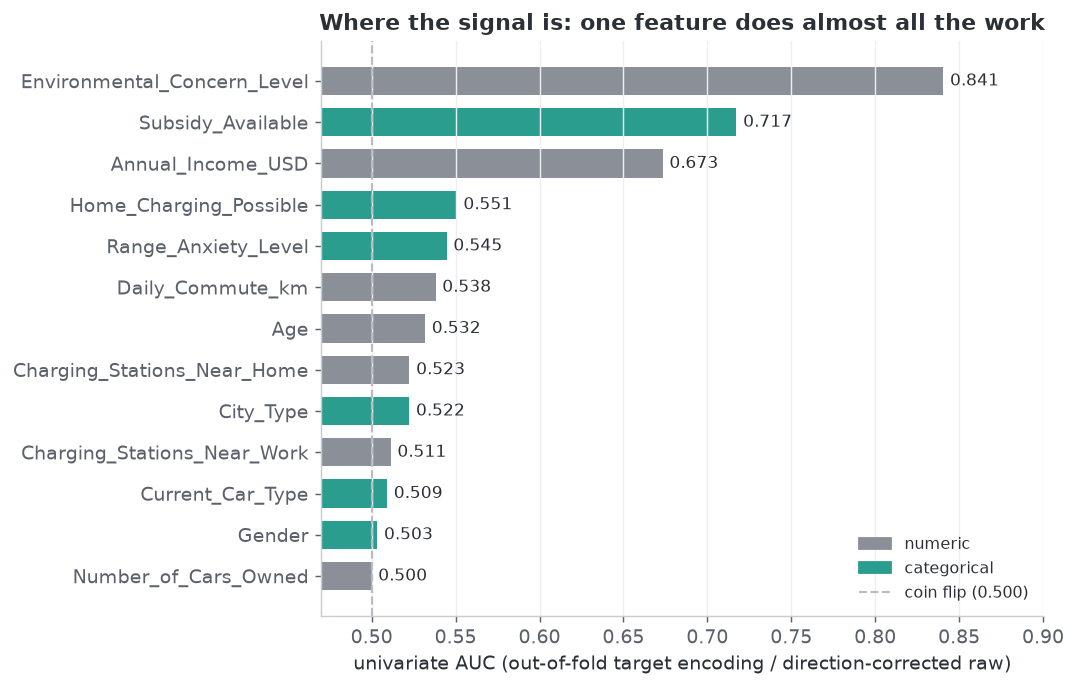

In [2]:
FEATS = [{"feature": "Environmental_Concern_Level", "kind": "numeric", "univariate_auc": 0.843521340965195, "binned_oof_auc": 0.8405774203252367}, {"feature": "Subsidy_Available", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.7173408736644842}, {"feature": "Annual_Income_USD", "kind": "numeric", "univariate_auc": 0.6703667708314164, "binned_oof_auc": 0.6733972515636033}, {"feature": "Home_Charging_Possible", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.5506585762469238}, {"feature": "Range_Anxiety_Level", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.544684033715986}, {"feature": "Daily_Commute_km", "kind": "numeric", "univariate_auc": 0.5337569407642957, "binned_oof_auc": 0.538069660675278}, {"feature": "Age", "kind": "numeric", "univariate_auc": 0.5055354685835938, "binned_oof_auc": 0.5318242347936774}, {"feature": "Charging_Stations_Near_Home", "kind": "numeric", "univariate_auc": 0.5158862771684991, "binned_oof_auc": 0.52250506468958}, {"feature": "City_Type", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.5224133207918611}, {"feature": "Charging_Stations_Near_Work", "kind": "numeric", "univariate_auc": 0.5106197902135918, "binned_oof_auc": 0.5113320072004807}, {"feature": "Current_Car_Type", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.5091901836292745}, {"feature": "Gender", "kind": "categorical", "univariate_auc": None, "binned_oof_auc": 0.5033628309285023}, {"feature": "Number_of_Cars_Owned", "kind": "numeric", "univariate_auc": 0.5039345085689741, "binned_oof_auc": 0.4999210317449456}]

order = sorted(FEATS, key=lambda d: d["binned_oof_auc"])
lab = [d["feature"] for d in order]
val = [d["binned_oof_auc"] for d in order]
col = [GREY if d["kind"] == "numeric" else TEAL for d in order]

fig, ax = plt.subplots(figsize=(8.4, 5.4))
bars = ax.barh(lab, val, color=col, height=0.68)
fl = ax.axvline(0.5, color="#b9bdc3", lw=1.2, ls="--", label="coin flip (0.500)")
for b, v in zip(bars, val):
    ax.text(v + 0.004, b.get_y() + b.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=9.5, color="#2b2f36")
ax.set_xlim(0.47, 0.90)
ax.set_xlabel("univariate AUC (out-of-fold target encoding / direction-corrected raw)")
ax.set_title("Where the signal is: one feature does almost all the work")
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=GREY), plt.Rectangle((0, 0), 1, 1, color=TEAL), fl]
ax.legend(handles, ["numeric", "categorical", "coin flip (0.500)"],
          loc="lower right", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()


1 feature  : 0.84288
3 features : 0.93540   (95.6% of the total gain comes from one feature)
7 features : 0.94000   <- peak
13 features: 0.93970   (-0.00031 vs the peak, i.e. nothing)

caveat: 200k subsample, one 3-fold run - differences below ~0.0003 are not significant.


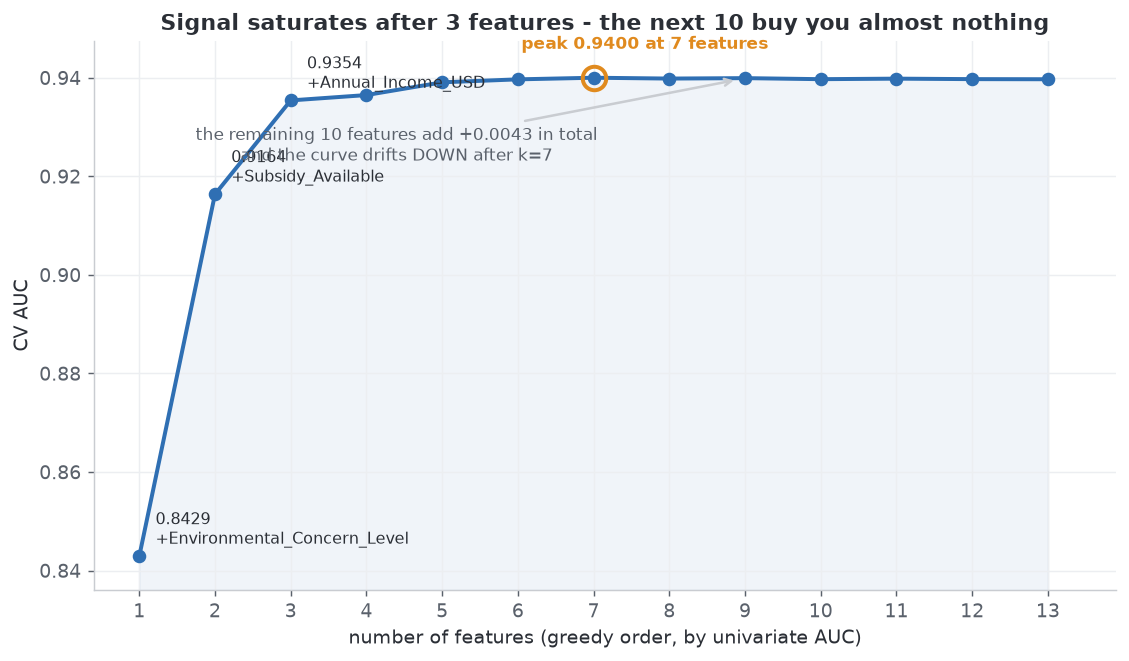

In [3]:
# Greedy build-up: add features in descending order of univariate AUC.
# Real measurement: LightGBM, 200k-row subsample, 3-fold CV, 400 rounds, identical params each step.
CUM = [{"k": 1, "added": "Environmental_Concern_Level", "auc": 0.8428795858306075}, {"k": 2, "added": "Subsidy_Available", "auc": 0.9163544637584438}, {"k": 3, "added": "Annual_Income_USD", "auc": 0.9353980095561848}, {"k": 4, "added": "Home_Charging_Possible", "auc": 0.9364854471930673}, {"k": 5, "added": "Range_Anxiety_Level", "auc": 0.939073881079047}, {"k": 6, "added": "Daily_Commute_km", "auc": 0.9396725347155072}, {"k": 7, "added": "Age", "auc": 0.9400014963821164}, {"k": 8, "added": "Charging_Stations_Near_Home", "auc": 0.939832375524587}, {"k": 9, "added": "City_Type", "auc": 0.93992042396229}, {"k": 10, "added": "Charging_Stations_Near_Work", "auc": 0.9397081225030212}, {"k": 11, "added": "Current_Car_Type", "auc": 0.9398147741465795}, {"k": 12, "added": "Gender", "auc": 0.9397179243693352}, {"k": 13, "added": "Number_of_Cars_Owned", "auc": 0.9396957271602882}]

k = [d["k"] for d in CUM]
a = [d["auc"] for d in CUM]
names = [d["added"] for d in CUM]

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.plot(k, a, "-o", color=BLUE, lw=2.2, ms=6.5, zorder=3)
ax.fill_between(k, 0.836, a, color=BLUE, alpha=0.07)
for i in (0, 1, 2):
    ax.annotate(f"{a[i]:.4f}\n+{names[i]}", (k[i], a[i]), textcoords="offset points",
                xytext=(9, 7), fontsize=9, color="#2b2f36")
ax.plot([7], [a[6]], "o", ms=13, mfc="none", mec=AMBER, mew=2.2, zorder=4)
ax.annotate(f"peak {a[6]:.4f} at 7 features", (7, a[6]), textcoords="offset points",
            xytext=(-40, 16), fontsize=9.5, color=AMBER, fontweight="bold")
ax.annotate("the remaining 10 features add +0.0043 in total\nand the curve drifts DOWN after k=7",
            xy=(8.9, 0.93960), xytext=(4.4, 0.9232), ha="center", fontsize=9.5, color="#5a616b",
            arrowprops=dict(arrowstyle="->", color="#c9ccd1", lw=1.4))
ax.set_xlim(0.4, 13.9); ax.set_ylim(0.836, 0.9475)
ax.set_xticks(k)
ax.set_xlabel("number of features (greedy order, by univariate AUC)")
ax.set_ylabel("CV AUC")
ax.set_title("Signal saturates after 3 features - the next 10 buy you almost nothing")
plt.tight_layout(); plt.show()

print(f"1 feature  : {a[0]:.5f}")
print(f"3 features : {a[2]:.5f}   ({100*(a[2]-a[0])/(a[-1]-a[0]):.1f}% of the total gain comes from one feature)")
print(f"7 features : {a[6]:.5f}   <- peak")
print(f"13 features: {a[-1]:.5f}   ({a[-1]-a[6]:+.5f} vs the peak, i.e. nothing)")
print()
print("caveat: 200k subsample, one 3-fold run - differences below ~0.0003 are not significant.")


**Takeaway:** **~96%** of the achievable gain comes from just three columns (`Environmental_Concern_Level`, `Subsidy_Available`, `Annual_Income_USD`). The remaining ten add **+0.0043 in total**, and the CV curve actually **peaks at 7 features** — past that you are fitting noise. Every idea you will be tempted by next (more models, deeper models, more features) operates inside that 0.0043. This is the measurement that made me stop guessing and start *auditing* (§3).


## 2. What actually moved the needle

Here is every submission I made, with the cross-validated score it was supposed to have and the public score it got.

| submission | CV (cross-fitted OOF) | public LB | LB − CV | family |
|---|---|---|---|---|
| LGBM baseline | 0.94150 | 0.94156 | +0.00006 | single model |
| LGBM + Optuna | 0.94188 | 0.94165 | -0.00023 | single model |
| LGBM + FE | 0.94180 | 0.94123 | -0.00057 | single model |
| LGBM + FE2 | 0.94203 | 0.94181 | -0.00022 | single model |
| Greedy blend | 0.94200 | 0.94185 | -0.00015 | early blend |
| Blend v2 | 0.94220 | 0.94187 | -0.00033 | early blend |
| Weighted ensemble | 0.94222 | 0.94148 | -0.00074 | early blend |
| LR stack (early) | 0.94246 | 0.94216 | -0.00030 | linear stack |
| LR stack (37 members) | 0.94275 | 0.94278 | +0.00003 | linear stack |
| Tree meta (no LB) | 0.94303 | — | — | non-linear meta |
| Leaf-linear meta + basis | 0.94320 | 0.94023 | -0.00297 | non-linear meta |
| Meta bagging (12 models) | 0.94323 | 0.94238 | -0.00085 | non-linear meta |

Read the last four rows carefully — that's the whole point of this notebook. The **linear stack is the best thing on the board** and its CV was accurate to +0.00003. The **non-linear variants scored higher in CV and lower on the leaderboard.**

The honest ladder, in one line:

> 0.9415 (single LGBM) → 0.9420 (feature engineering) → 0.9422 (weighted blend) → 0.9425 (linear stack, 31 members) → **0.9428 (curated 37 members)** → *CV says 0.9432, leaderboard says no.*

**+0.0013 of real gain, and none of it came from a cleverer model.** It came from:
1. a **curated** member set (not "all members"),
2. **paired-fold** evaluation so candidate differences weren't buried in fold noise,
3. refusing to trust any gain smaller than the measured noise floor.


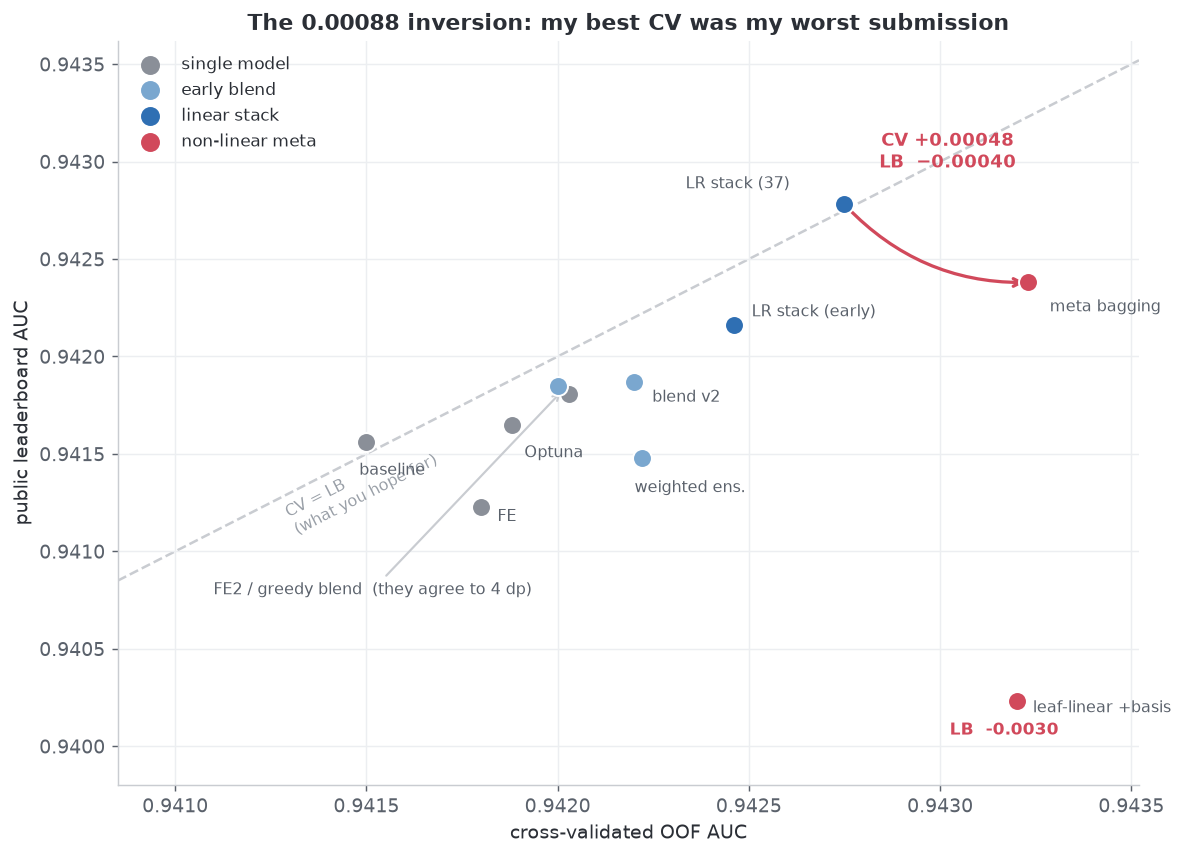

In [4]:
LADDER = [{"label": "LGBM baseline", "cv": 0.9415, "lb": 0.94156, "family": "single model"}, {"label": "LGBM + Optuna", "cv": 0.94188, "lb": 0.94165, "family": "single model"}, {"label": "LGBM + FE", "cv": 0.9418, "lb": 0.94123, "family": "single model"}, {"label": "LGBM + FE2", "cv": 0.94203, "lb": 0.94181, "family": "single model"}, {"label": "Greedy blend", "cv": 0.942, "lb": 0.94185, "family": "early blend"}, {"label": "Blend v2", "cv": 0.9422, "lb": 0.94187, "family": "early blend"}, {"label": "Weighted ensemble", "cv": 0.94222, "lb": 0.94148, "family": "early blend"}, {"label": "LR stack (early)", "cv": 0.94246, "lb": 0.94216, "family": "linear stack"}, {"label": "LR stack (37 members)", "cv": 0.94275, "lb": 0.94278, "family": "linear stack"}, {"label": "Tree meta (no LB)", "cv": 0.94303, "lb": None, "family": "non-linear meta"}, {"label": "Leaf-linear meta + basis", "cv": 0.9432, "lb": 0.94023, "family": "non-linear meta"}, {"label": "Meta bagging (12 models)", "cv": 0.94323, "lb": 0.94238, "family": "non-linear meta"}]
sub = [d for d in LADDER if d["lb"] is not None]
SHORT = {"LGBM baseline": "baseline", "LGBM + Optuna": "Optuna", "LGBM + FE": "FE", "LGBM + FE2": "FE2", "Greedy blend": "greedy blend", "Blend v2": "blend v2", "Weighted ensemble": "weighted ens.", "LR stack (early)": "LR stack (early)", "LR stack (37 members)": "LR stack (37)", "Tree meta (no LB)": "tree meta", "Leaf-linear meta + basis": "leaf-linear +basis", "Meta bagging (12 models)": "meta bagging"}

lo, hi = 0.94085, 0.94352
fig, ax = plt.subplots(figsize=(9.3, 6.7))
ax.plot([lo, hi], [lo, hi], ls="--", lw=1.4, color="#c9ccd1", zorder=0)
ax.text(0.94128, 0.94106, "CV = LB\n(what you hope for)", color="#9aa0a8", fontsize=9,
        rotation=27, ha="left", va="bottom")

for d in sub:
    ax.scatter(d["cv"], d["lb"], s=110, color={"single model": "#8a8f98", "early blend": "#7aa7cf", "linear stack": "#2f6fb3", "non-linear meta": "#d1495b", "other": "#2a9d8f"}[d["family"]],
               zorder=4, edgecolor="white", linewidth=1.1)

offs = {"LGBM baseline": (-4, -18), "LGBM + Optuna": (7, -18), "LGBM + FE": (9, -8),
        "Blend v2": (10, -11), "Weighted ensemble": (-4, -19), "LR stack (early)": (10, 5),
        "LR stack (37 members)": (-88, 9), "Meta bagging (12 models)": (12, -16),
        "Leaf-linear meta + basis": (9, -6)}
skip = ("LGBM + FE2", "Greedy blend")

for d in sub:
    if d["label"] in skip:
        continue
    ax.annotate(SHORT[d["label"]], (d["cv"], d["lb"]), textcoords="offset points",
                xytext=offs.get(d["label"], (8, 6)), fontsize=9, color="#5a616b")

# FE2 and Greedy blend landed within 4 dp of each other - label them as one cluster.
cl = [d for d in sub if d["label"] in skip]
cx = float(np.mean([d["cv"] for d in cl])); cy = float(np.mean([d["lb"] for d in cl]))
ax.annotate("FE2 / greedy blend  (they agree to 4 dp)", xy=(cx, cy), xytext=(0.94110, 0.94078),
            fontsize=9, color="#5a616b", ha="left",
            arrowprops=dict(arrowstyle="->", color="#c9ccd1", lw=1.2))

ax.annotate("", xy=(0.94323, 0.94238), xytext=(0.94275, 0.94278),
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.8,
                            connectionstyle="arc3,rad=0.22"))
ax.text(0.94302, 0.94297, "CV +0.00048\nLB  −0.00040", color=RED, fontsize=10,
        ha="center", fontweight="bold")
ax.text(0.94331, 0.94006, "LB  -0.0030", color=RED, fontsize=9.5, ha="right", fontweight="bold")

for fam, c in {"single model": "#8a8f98", "early blend": "#7aa7cf", "linear stack": "#2f6fb3", "non-linear meta": "#d1495b", "other": "#2a9d8f"}.items():
    if any(d["family"] == fam for d in sub):
        ax.scatter([], [], s=90, color=c, label=fam)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
ax.set_xlim(lo, hi); ax.set_ylim(0.93980, 0.94362)
ax.set_xlabel("cross-validated OOF AUC"); ax.set_ylabel("public leaderboard AUC")
ax.set_title("The 0.00088 inversion: my best CV was my worst submission")
plt.tight_layout(); plt.show()


## 3. Seventeen things that did not work

This is the table I wish I'd had on day one. Every row is a **measured** result, not a hunch.

| # | idea | measured | verdict |
|---|---|---|---|
| 1 | Plain MLP / RealMLP-style net | 0.9367 (fold 0) | −0.0045 vs GBDT — dropped |
| 2 | Logistic regression, one-hot + bins + interactions | 0.9394 | −0.0022; blend weight ≈ 0 |
| 3 | ExtraTrees | 0.9392 | dropped |
| 4 | Monotone constraints (2 variants) | 0.9404 / 0.9404 | −0.0015; 4 assumed-monotone features aren't (Spearman −0.02) |
| 5 | RandomForest | 0.9407 | dropped |
| 6 | XGBoost | 0.9417 | ±0.0000 — kept as a member only |
| 7 | HistGradientBoosting (sklearn) | 0.9417 | ±0.0000 — kept as a member only |
| 8 | Nested cross target encoding, 9 key combos | 0.9415 | blend weight 0 |
| 9 | CatBoost, max_ctr_complexity=4 | 0.9416 | blend weight 0 |
| 10 | Original source dataset (10k rows) added to training | 0.9417 | blend weight 0 |
| 11 | Original source dataset as the ONLY training set | 0.9377 (best of 4 capacities) | far worse — 10k rows can't beat 669k |
| 12 | 10-fold instead of 5-fold + full-data refit | +0.00005 / +0.00000 | below noise for 3× the cost |
| 13 | Rank-averaging instead of probability-averaging | 0.94222 = 0.94222 | identical — members were already calibrated |
| 14 | Greedy weight search over 44 → 49 members | 0.94246 / 0.94259 | worse than the curated 37 (0.94275): more ≠ better |
| 15 | Nystroem RBF kernel approximation | 0.9349 | dropped |
| 16 | Pseudo-labelling | bounded by the row above | +25% training data bought +0.00005 → not worth it |
| 17 | Non-linear / leaf-linear stacking | CV 0.94303–0.94323 (+0.0005) | **FALSIFIED ON LB: −0.0004 … −0.0030 (section 5)** |

Three generalisable lessons fall out of it:

1. **Synthetic tabular data punishes complexity.** Every "clever" model (MLP, kernel approximation, ExtraTrees) lost to a plain gradient-boosted tree. The generative process is mostly monotone + a gate, and GBDTs already nail that shape.
2. **External data is not automatically a win.** This competition is generated from a real 10k-row dataset, and adding it changed nothing (weight 0). With 669k synthetic rows, 10k real rows are a rounding error — the *signal* has to be new, not just the *data*.
3. **"Weight 0" conclusions need a scale check first** (see §4) — one of my rounds of conclusions was pure artefact.


## 4. A silent bug that invalidated a whole round of conclusions

I used a greedy forward-selection blender that accumulated **unnormalised weighted sums** instead of normalised probabilities. Nothing raised an error — the "weights" still looked sane and the internal AUC comparisons still ranked candidates. But the stored blend output had:

- min 0.0006, max **15.9**, mean 4.64
- **51.9% of values ≥ 1**

Then a downstream script did the standard `clip(1e-6, 1-1e-6)` before taking a logit — which collapses every value above 1 to the same number. Result: the blend's logit-space AUC read **0.7865** while its raw AUC was **0.9422**.

I spent a whole round of experiments concluding "model X contributes nothing (weight = 0)" before noticing. **Every one of those conclusions was an artefact of the scale, not a property of the model.** The demo below shows exactly how badly this can fail.


In [5]:
# Minimal reproduction of the failure mode. No data needed.
rng = np.random.default_rng(0)
n = 60_000
y = (rng.random(n) < 0.175).astype(int)

def make_member(alpha):
    s = alpha * y + rng.normal(0, 1, n)
    return 1 / (1 + np.exp(-s))          # a well-behaved member in [0, 1]

m1, m2, m3 = make_member(1.5), make_member(1.4), make_member(1.3)
# BUG: weighted SUM without normalising the weights (weights here sum to 3.0)
buggy = 1.0 * m1 + 1.0 * m2 + 1.0 * m3
# FIX: weighted MEAN
fixed = (m1 + m2 + m3) / 3.0

def auc(y, s):
    from sklearn.metrics import roc_auc_score
    return roc_auc_score(y, s)

def logit_auc(y, s):
    p = np.clip(s, 1e-6, 1 - 1e-6)
    return auc(y, np.log(p / (1 - p)))

print(f"sum blend : range {buggy.min():.3f} .. {buggy.max():.3f}   "
      f"share >= 1: {(buggy >= 1).mean():.1%}")
print()
print(f"  raw AUC  (sum blend)   : {auc(y, buggy):.5f}")
print(f"  logit AUC (sum blend)  : {logit_auc(y, buggy):.5f}   <-- clipped, ties collapse it")
print(f"  raw AUC  (mean blend)  : {auc(y, fixed):.5f}")
print(f"  logit AUC (mean blend) : {logit_auc(y, fixed):.5f}   <-- unaffected")
print()
print("Same members, same information, same 'quality' - one line of normalisation apart.")


sum blend : range 0.301 .. 2.925   share >= 1: 93.0%

  raw AUC  (sum blend)   : 0.95301
  logit AUC (sum blend)  : 0.54258   <-- clipped, ties collapse it
  raw AUC  (mean blend)  : 0.95301
  logit AUC (mean blend) : 0.95301   <-- unaffected

Same members, same information, same 'quality' - one line of normalisation apart.


**Rule I now follow:** before trusting *any* downstream metric on a blend, assert

```python
assert (0 <= p).all() and (p <= 1).all(), f"blend is not a probability: {p.min():.3g}..{p.max():.3g}"
```

and when comparing two candidates, compare them in the **same space** (both raw, or both gaussianised ranks) — never one raw and one logit.


## 5. The part worth your time: a CV gain that didn't survive the leaderboard

Up to §2 everything was conventional. Then I made a common move: **replace the global linear combiner with something more expressive.**

The task: given 37 member predictions, learn the best way to combine them. A global linear model (logistic regression / non-negative least squares) is the default. I tried:

| combiner | CV (cross-fitted OOF) | public LB |
|---|---|---|
| global linear (37 members) | **0.94275** | **0.94278** |
| shallow LightGBM, members only | 0.94301 | — |
| + raw features | 0.94303 | — |
| leaf-linear tree (`linear_tree=True`) | 0.94309 | — |
| + explicit basis (pairwise diffs, raw signals, PCA) | 0.94320 | 0.94023 |
| rank-average of several such metas | **0.94323** | 0.94238 |

The CV number went up **monotonically** with combiner expressiveness — a clean, believable **+0.00048**. Ablations were consistent: the gain came from non-linearity in member space (members-only ≈ members + raw features), monotone constraints *hurt*, and a smoothness diagnostic passed.

So I submitted it. **It scored lower than the linear stack** — and the fancier it was, the worse it did.

### It is not leaderboard noise

This is the part people skip, and it's the part that makes the result real. The public leaderboard is ~30% of the test set, and a *single* submission's score wobbles a lot:

| subset | SD of one submission's AUC | SD of the PAIRED difference A−B |
|---|---|---|
| 20% (133,733 rows) | 0.00062 | 0.00006 |
| 30% (200,599 rows) | 0.00049 | 0.00005 |
| 75% (501,498 rows) | 0.00016 | 0.00002 |

I measured this by resampling rows and recomputing AUC — but the important column is the third one. Because two near-identical submissions (Spearman **0.9965**) share almost all of their mistakes, the **paired** difference is **~10× more stable** than either score alone. So a −0.00040 gap is **≈8σ**, not noise.

**Practical rule:** to judge whether candidate A beats B, never compare their absolute LB scores. Compare the *paired difference*, and calibrate its SD the same way.


paired SD at public-LB scale : 0.00005
observed LB gap              : -0.00040
z-score                      : 8.0 sigma

=> the non-linear combo is genuinely worse on held-out data, not unlucky.


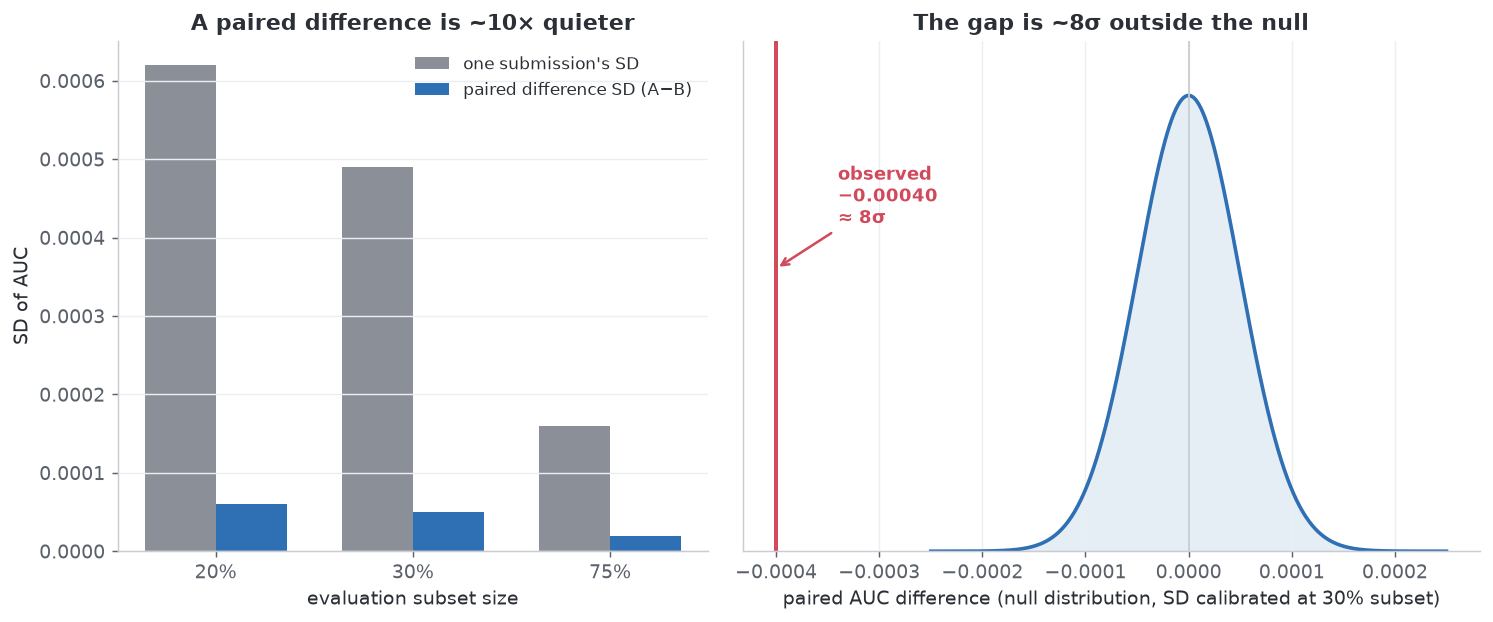

In [6]:
NOISE = [{"subset": "20% (133,733 rows)", "sd_single": 0.00062, "sd_paired": 6e-05}, {"subset": "30% (200,599 rows)", "sd_single": 0.00049, "sd_paired": 5e-05}, {"subset": "75% (501,498 rows)", "sd_single": 0.00016, "sd_paired": 2e-05}]
OBS = 0.0004   # observed LB gap: tree meta (0.94238) vs linear stack (0.94278)

x = np.arange(len(NOISE)); w = 0.36
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.9), gridspec_kw={"width_ratios": [1, 1.25]})

ax1.bar(x - w/2, [d["sd_single"] for d in NOISE], w, color=GREY, label="one submission's SD")
ax1.bar(x + w/2, [d["sd_paired"] for d in NOISE], w, color=BLUE, label="paired difference SD (A−B)")
ax1.set_xticks(x); ax1.set_xticklabels([d["subset"].split(" (")[0] for d in NOISE])
ax1.set_xlabel("evaluation subset size"); ax1.set_ylabel("SD of AUC")
ax1.set_title("A paired difference is ~10× quieter")
ax1.legend(frameon=False, fontsize=9.5); ax1.grid(axis="x", visible=False)

p2 = NOISE[1]["sd_paired"]
xs = np.linspace(-5 * p2, 5 * p2, 500)
ax2.plot(xs, np.exp(-0.5 * (xs / p2) ** 2), color=BLUE, lw=2)
ax2.fill_between(xs, 0, np.exp(-0.5 * (xs / p2) ** 2), color=BLUE, alpha=0.12)
ax2.axvline(0, color="#c9ccd1", lw=1)
ax2.axvline(-OBS, color=RED, lw=2.2)
ax2.annotate(f"observed\n−{OBS:.5f}\n≈ {OBS/p2:.0f}σ", xy=(-OBS, 0.62), xytext=(-0.00034, 0.72),
             color=RED, fontsize=10, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.4))
ax2.set_xlabel("paired AUC difference (null distribution, SD calibrated at 30% subset)")
ax2.set_yticks([]); ax2.set_title("The gap is ~8σ outside the null")
ax2.set_ylim(0, 1.12)
plt.tight_layout(); plt.show()

print(f"paired SD at public-LB scale : {p2:.5f}")
print(f"observed LB gap              : -{OBS:.5f}")
print(f"z-score                      : {OBS/p2:.1f} sigma")
print()
print("=> the non-linear combo is genuinely worse on held-out data, not unlucky.")


## 6. Root cause: the two sides have a different *aggregation order*

This is the mechanism, and I believe it generalises well beyond this competition.

|  | training representation (what the combiner fits on) | deployment representation (what it's applied to) |
|---|---|---|
| member column = | the prediction of **one** model that never saw the row | the **average of K=5** fold models (or a full-data refit) |
| per-column noise | σ | ≈ σ/√K |
| measured mean pairwise |corr| of the member matrix | **0.9383** | **0.9519** |

Both columns are *honest* — no leakage anywhere. But they are **not the same random variable**: one carries a single model's idiosyncratic error, the other has had it averaged away.

A tree-based combiner can and will exploit that difference. It learns splits of the form *"member A is unusually high **relative to** member B"* — and the population of rows where that split fires depends on the **noise level** of the columns. Calibrate the splits on σ, deploy them on σ/√K, and the learned corrections get applied to the wrong rows. **The more expressive the combiner, the more of this it can fit** — which is exactly why the CV score *rose* monotonically with capacity while the leaderboard score *fell*.

A **global linear** combiner is structurally immune: it estimates first moments only, and `E[average of K models] ≈ E[one model]`. It has nothing to mis-calibrate.

### Two honest caveats

- **I saw the mismatch coming and my diagnostic still passed.** I built a "pseudo-test" matrix by shrinking OOF columns toward the row consensus until their correlation matched the measured test-side value — and the score held (0.94314 → 0.94313). I took that as clearance. It wasn't. **Lesson: reproducing one moment (correlation) of a distributional shift does not reproduce the shift.** If the train and deploy representations come from different pipelines, cross-validation on the train-side representation *structurally cannot* certify the combiner.
- **The PCA variant was catastrophic (−0.0030), and that part is more mundane:** PCA axes are the maximum-variance directions, and much of that variance *is* the between-side noise difference; fitting PCA per-fold for OOF but on all rows for deployment rotates the axes relative to what the meta learned. Coordinates derived from the training-side representation are the worst possible thing to hand a non-linear combiner.

### The fix (if you want to keep the non-linear combiner)

Do **not** change the combiner — change the representation so both sides have the **same aggregation order**:

> run **repeated K-fold with different seeds**, and for each row average its out-of-fold predictions **across replicates**. Then every OOF column = an average of K models that never saw that row, structurally identical to the test column.

Cost: K× training for the affected members (you only need it for the highest-weighted ~10). I did not run this round — I'm reporting the diagnosis, not a validated fix. **If you try it, I'd genuinely like to know whether it closes the gap.**


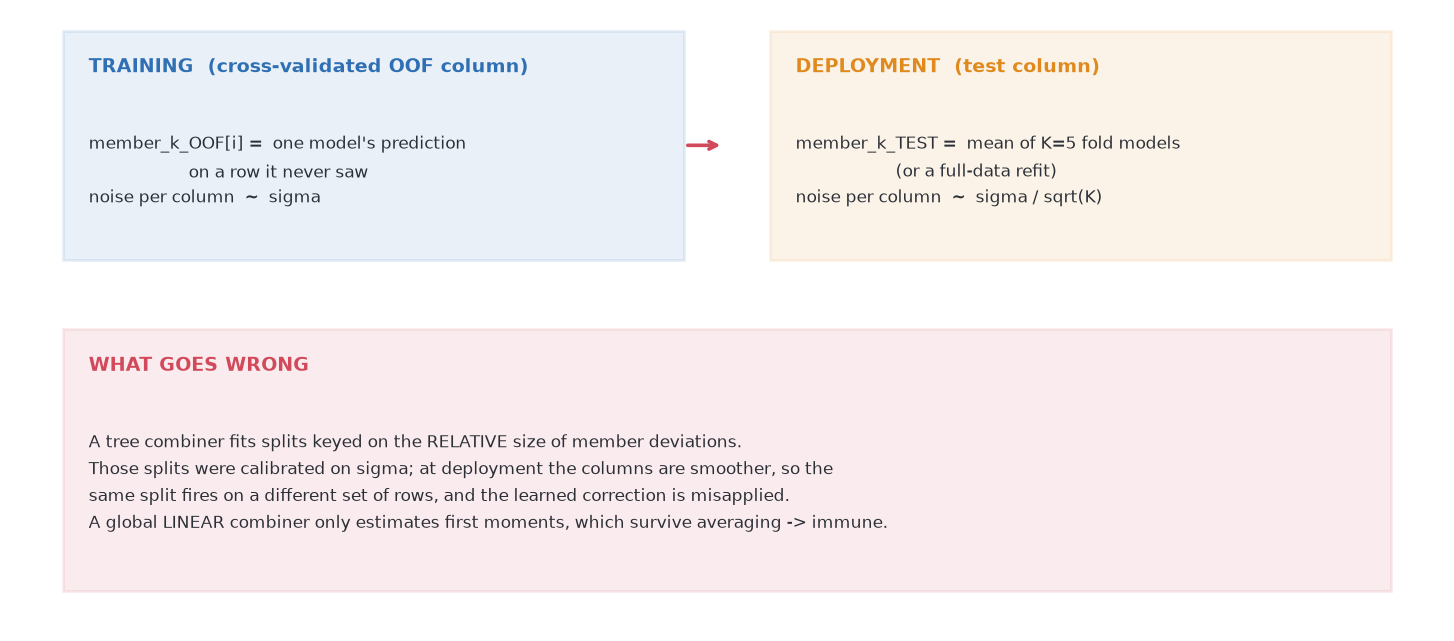

In [7]:
# Conceptual picture of the mismatch.
fig, ax = plt.subplots(figsize=(11.3, 5.05))
ax.set_xlim(0, 10); ax.set_ylim(0, 5.05); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, alpha=0.10,
                               edgecolor=color, lw=1.6, zorder=2))
    ax.text(x + 0.18, y + h - 0.34, title, fontsize=10.5, fontweight="bold",
            color=color, zorder=3)
    ax.text(x + 0.18, y + h - 0.82, body, fontsize=9.6, color="#2b2f36",
            va="top", zorder=3, linespacing=1.55)

box(0.35, 3.02, 4.35, 1.88, "TRAINING  (cross-validated OOF column)",
    "member_k_OOF[i] =  one model's prediction\n"
    "                    on a row it never saw\n"
    "noise per column  ~  sigma", BLUE)
box(5.30, 3.02, 4.35, 1.88, "DEPLOYMENT  (test column)",
    "member_k_TEST =  mean of K=5 fold models\n"
    "                    (or a full-data refit)\n"
    "noise per column  ~  sigma / sqrt(K)", AMBER)

ax.annotate("", xy=(4.98, 3.96), xytext=(4.70, 3.96),
            arrowprops=dict(arrowstyle="->", color=RED, lw=2))
box(0.35, 0.30, 9.30, 2.15, "WHAT GOES WRONG",
    "A tree combiner fits splits keyed on the RELATIVE size of member deviations.\n"
    "Those splits were calibrated on sigma; at deployment the columns are smoother, so the\n"
    "same split fires on a different set of rows, and the learned correction is misapplied.\n"
    "A global LINEAR combiner only estimates first moments, which survive averaging -> immune.", RED)

plt.tight_layout(); plt.show()


## 7. Checklist for a dense leaderboard

Extracted from the six rounds above. All of these are cheap; two of them would have saved me entire days.

1. **Find the ceiling before optimising.** Measure the strongest single feature and the all-features model. Here: one column gives **0.841**, all thirteen give **~0.940**, and the CV curve **peaks at 7 features**. You are fighting over the last ~0.004 — and after my fourth model family, each new one moved the stack by ~1e-5. When headroom is 1e-5, stop tuning models and go do the audit; that's where all the real findings were.
2. **Compare candidates on paired folds.** Use identical splits for A and B, then look at `AUC_A − AUC_B`. Fold noise cancels; per-fold differences of 1e-5 become meaningful.
3. **Calibrate leaderboard noise with a *paired* bootstrap**, not the SD of one submission (0.00049 vs 0.00005 here — a 10× difference in sensitivity).
4. **Never trust a non-linear combiner whose training and deployment inputs come from different pipelines.** Cross-validation structurally cannot see this. Either match the aggregation order (repeated K-fold), or ship a linear combiner.
5. **Assert your blends are probabilities** before any logit/clip step (§4).
6. **More members is not monotonically better.** My best set was 37 curated members; 44 and 49 scored *worse* with the same combiner. And a k-NN member with its own AUC of only **0.8975** contributed **+0.00021** to the stack — *instance-based diversity is worth more than accuracy.*
7. **Pin the exact member list** when screening. I once used "all members minus family F"; family F grew from 4 to 6 names between rounds, silently changing the candidate set and making every option look worse.
8. **Re-measure a known answer after every refactor.** Two lines of code; it caught the drift in (7).

## Closing

I did not reach the top of this leaderboard. The top score was **0.94672**; I finished around **0.9428**, and I spent a long time on the 0.004 in between. What I eventually concluded — after falsifying 17 approaches, all of them legitimate modelling ideas — is that the gap is very unlikely to be reachable by better modelling of *this* data. Which is fine, because the thing I actually learned was in §5–§6, and that one transfers.

If you have a better explanation for the aggregation-order effect — or a counter-example where a non-linear stack *did* transfer — please tell me in the comments. That's the part I'm least sure about.

<sub>Competition: [Playground Series S6E9](https://www.kaggle.com/competitions/playground-series-s6e9) · Metric: ROC AUC · Cross-validation: 5-fold stratified, fixed seed, paired across candidates · Public leaderboard ≈ 30% of test. All numbers are my own measurements, reproduced here from inlined values so the notebook needs no data to run.</sub>


## Appendix — recompute §1 on the real data (optional)

If this notebook is attached to the competition data, the cell below recomputes the univariate AUC table live. If the data isn't attached, it skips cleanly.


In [8]:
# Optional: recompute the §1 table from the actual competition data.
# Requires  train.csv  (attach  'Predicting Electric Vehicle Purchases'  as input data).
import os
path = None
for root, _, files in os.walk("/kaggle/input"):
    if "train.csv" in files:
        path = os.path.join(root, "train.csv"); break

if path is None:
    print("train.csv not found under /kaggle/input - skipping (the notebook is a postmortem; "
          "every number above is already inlined).")
else:
    import pandas as pd
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import StratifiedKFold

    tr = pd.read_csv(path, low_memory=False)
    tgt = [c for c in tr.columns if "Buy_EV" in c][0]
    y = (tr[tgt] == "Yes").astype(int).values
    num = tr.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore").columns.tolist()
    cat = [c for c in tr.columns if tr[c].dtype == object and c != tgt]
    skf = StratifiedKFold(5, shuffle=True, random_state=2024)
    rows = []
    for c in num:
        v = tr[c].values.astype(float)
        rows.append((c, "numeric", max(roc_auc_score(y, v), 1 - roc_auc_score(y, v))))
    for c in cat:
        code = pd.factorize(tr[c])[0]
        enc = np.zeros(len(y))
        for tri, vai in skf.split(code, y):
            m = pd.Series(y[tri]).groupby(code[tri]).mean()
            enc[vai] = pd.Series(code[vai]).map(m).fillna(y[tri].mean()).values
        rows.append((c, "categorical", roc_auc_score(y, enc)))
    out = pd.DataFrame(rows, columns=["feature", "type", "univariate_auc"]).sort_values(
        "univariate_auc", ascending=False)
    out["univariate_auc"] = out["univariate_auc"].round(4)
    print(out.to_string(index=False))


train.csv not found under /kaggle/input - skipping (the notebook is a postmortem; every number above is already inlined).
